# Tohoku Tsunami — Open Elevation Data

This notebook runs the 2011 Tohoku tsunami simulation using **freely available**
global bathymetry/topography instead of the proprietary `Tohoku.pts` file.

Elevation source: **NOAA NCEI Global DEM Mosaic** (GEBCO-based), downloaded via
the ArcGIS ImageServer REST API — no registration or API key required.
- 15 arc-second (~450 m) resolution
- Land topography (SRTM-derived) + ocean bathymetry (GEBCO)
- Coverage: global

Earthquake source: KL random slip field (Karhunen–Loève expansion) via `okada_kl_subfaults`.

Gauge data from https://www.ngdc.noaa.gov/hazard/dart/2011honshu_dart.html

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import anuga
import okada_kl_subfaults as okl

%matplotlib inline
%load_ext autoreload
%autoreload 2

from matplotlib import rc
rc('animation', html='jshtml')

In [2]:
try:
    os.chdir('Tohoku')
except:
    pass
print(f'Working directory: {os.getcwd()}')

Working directory: /home/steve/Projects/Tohoku


## Download Elevation Data

Downloads a GeoTIFF covering the simulation domain from the NOAA NCEI Global DEM
Mosaic.  The file is ~19 MB and is skipped on subsequent runs if it already exists.

In [3]:
from download_elevation import download_noaa_dem

# Simulation DEM: covers the ANUGA model domain at full 15 arcsec resolution.
dem_file = 'Tohoku_dem.tif'

if not os.path.exists(dem_file):
    download_noaa_dem(dem_file, resolution_arcsec=15, padding_deg=0.5, verbose=True)
else:
    print(f'Using existing {dem_file}')

# Overview DEM: the whole Japanese archipelago plus DART 21418, used only for
# the locality map below.  Coarse (60 arcsec) since it is never interpolated
# onto the mesh -- keeps the download to ~6 MB.
japan_dem_file = 'Japan_dem.tif'
japan_dem_bounds = (127.0, 150.5, 29.5, 46.5)   # lon_min, lon_max, lat_min, lat_max

if not os.path.exists(japan_dem_file):
    download_noaa_dem(japan_dem_file, bounds=japan_dem_bounds,
                      resolution_arcsec=60, padding_deg=0.0, verbose=True)
else:
    print(f'Using existing {japan_dem_file}')


Using existing Tohoku_dem.tif
Using existing Japan_dem.tif


## Gauge Locations

In [4]:
import utm

class Gauge:
    def __init__(self, long, lat, t1=0.0, t2=1.e10):
        self.lat  = lat
        self.long = long
        self.t1   = t1
        self.t2   = t2
        east, north, zone_no, zone_letter = utm.from_latlon(lat, long, force_zone_number=54)
        self.east        = east
        self.north       = north
        self.zone_no     = zone_no
        self.zone_letter = zone_letter

gauges = {}
gauges[21418] = Gauge(148.694, 38.711)          # DART buoy used for validation
gauges[21401] = Gauge(152.583, 42.617, t1=1800.)
gauges[21413] = Gauge(152.117, 30.515, t1=1800.)
gauges[21419] = Gauge(155.736, 44.455, t1=1800.)
gauges[0]     = Gauge(141.0,   38.0)             # nearshore points
gauges[1]     = Gauge(141.0,   38.125)
gauges[2]     = Gauge(141.0,   38.25)

# Sendai plain: coast to onshore, for the stage / run-up investigation below.
# Keys are names so they can be added to or reordered without touching plots.
sendai_gauges = {
    'Sendai Bay (offshore)': Gauge(141.250, 38.250),
    'Arahama (nearshore)':   Gauge(140.985, 38.210),
    'Gamo':                  Gauge(141.010, 38.265),
    'Shiogama port':         Gauge(141.022, 38.317),
    'Nobiru':                Gauge(141.100, 38.335),
    'Yuriage':               Gauge(140.950, 38.170),
    'Sendai airport':        Gauge(140.930, 38.140),
}

# Inland transect at 38.21 N, from just offshore to above the run-up limit.
transect_lat  = 38.21
transect_lons = [140.995, 140.985, 140.970, 140.955, 140.940,
                 140.925, 140.910, 140.895, 140.880, 140.865, 140.850]
transect_gauges = [Gauge(lon, transect_lat) for lon in transect_lons]


## Fault Parameters (KL slip field)

In [5]:
km = 1000.0

# Fault-plane centre in UTM Zone 54N (absolute coordinates).  Note this is the
# centre of the rupture plane, not the catalogue epicentre (USGS 38.322N
# 142.369E -> 619670, 4242429; JMA -> 663081, 4218877).
#
# Nominal value is x0 = 720000.0.  Shifted 40 km west to better match the
# arrival time at DART 21418: it lengthens the source-to-buoy path from 463 km
# to 502 km, delaying arrival by ~3 min.
x0 = 720000.0 - 40_000
y0 = 4200000.0

fault_parameters = dict(
    depth   = 20 * km,
    length  = 200 * km,
    width   =  50 * km,
    strike  = 195.0,
    dip     =  14.0,
    rake    =  87.0,
    slip    =  60.0, #35.0
    opening =   0.0,
    nu      =   0.25,
)

## Build ANUGA Domain

In [6]:
import project

domain = anuga.create_domain_from_regions(
    project.bounding_polygon,
    boundary_tags={'bottom': [0], 'ocean_east': [1], 'top': [2], 'onshore': [3]},
    maximum_triangle_area=project.res_whole,
    interior_regions=project.interior_regions,
    use_cache=False,
    verbose=False,
)

domain.set_epsg(32654)  # WGS 84 / UTM zone 54N
domain.set_collect_max_quantities()
#domain.set_omp_num_threads(12)   # OpenMP is process-wide, not per-domain
domain.set_compute_mode('unified')

xll = domain.geo_reference.xllcorner
yll = domain.geo_reference.yllcorner

print(f'Triangles : {len(domain)}')
print(f'Extent    : {domain.get_extent()}')
print(f'Geo ref   : {domain.geo_reference}')

Area of bounding polygon = 501600.00 km^2
--------------------------------------------------------------------------------
Polygon  Max triangle area (m^2)  Total area (km^2)  Estimated #triangles
--------------------------------------------------------------------------------
Interior 15000000                 88753.41           5916
Interior 3600000                  30241.19           8400
Interior 60000                    11288.13           188135
Bounding 15000000                 371317.27          24754
Estimated total number of triangles: 324581
Number of triangles: 324581
output directory: /home/steve/Projects/Tohoku/_output_Caltech
source directory: /home/steve/Projects/Tohoku/sources/Caltech.pts
Note: This is generally about 20% less than the final amount


Triangles : 354946
Extent    : (np.float64(0.0), np.float64(880000.0), np.float64(0.0), np.float64(570000.0))
Geo ref   : (zone=54, easting=420000.000000, northing=3950000.000000, hemisphere=northern, epsg=32654)


## Set Elevation from Downloaded GeoTIFF

ANUGA reads the tif directly via `tif2point_values`, which reprojects the domain
centroid coordinates (UTM Zone 54N) to EPSG:4326 and looks up bilinearly
interpolated values from the raster.

In [7]:
domain.set_quantity('elevation', filename=dem_file, location='centroids', verbose=True)

domain.set_name('tohoku_open_dem')

tide = 0.0
domain.set_quantity('stage', tide)

# Ensure stage >= elevation on land (no water below ground)
Elevation = domain.quantities['elevation'].centroid_values
Stage     = domain.quantities['stage'].centroid_values
Stage[:] = np.maximum(Elevation, Stage)

print(f'Elevation range: {Elevation.min():.1f} m to {Elevation.max():.1f} m')

Applying fitted data to quantity
Elevation range: -8012.1 m to 1831.9 m


## Locality Map

The whole Japanese archipelago, showing the Okada fault centre, DART buoy 21418,
the ANUGA model domain, and the red box marking the Tohoku coastal region used
for the inundation close-up further down.


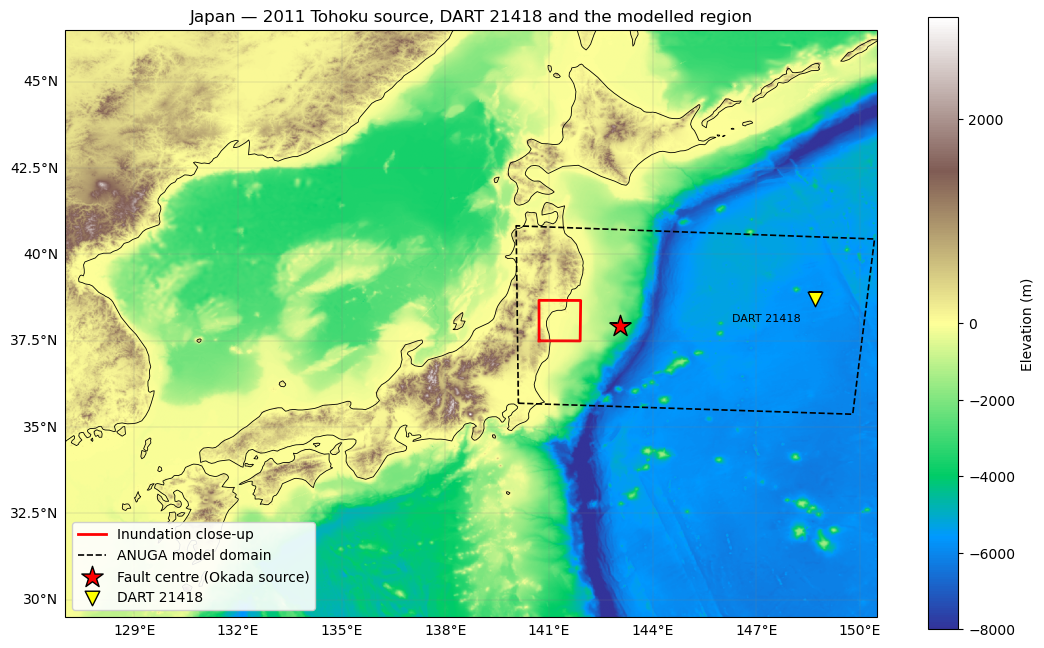

In [8]:
import rasterio
import cartopy.crs as ccrs
from matplotlib.colors import TwoSlopeNorm

# Tohoku coastal region shown in the inundation close-up (UTM Zone 54N metres).
# Defined here so the box drawn on this map and the close-up extent cannot drift.
closeup_extent = [475_000, 580_000, 4_150_000, 4_280_000]


def utm_box(extent, n=50):
    """Densified outline of a UTM rectangle, so it projects correctly."""
    xmin, xmax, ymin, ymax = extent
    xs = np.linspace(xmin, xmax, n)
    ys = np.linspace(ymin, ymax, n)
    x = np.concatenate([xs, np.full(n, xmax), xs[::-1], np.full(n, xmin)])
    y = np.concatenate([np.full(n, ymin), ys, np.full(n, ymax), ys[::-1]])
    return np.append(x, x[0]), np.append(y, y[0])


def add_scalebar(ax, length_km=25, location=(0.07, 0.06), zone=54):
    """Draw a bar of known ground length on a UTM axes (exact: axes are metres)."""
    import matplotlib.patheffects as pe

    xmin, xmax, ymin, ymax = ax.get_extent(crs=ccrs.UTM(zone=zone))
    x = xmin + location[0] * (xmax - xmin)
    y = ymin + location[1] * (ymax - ymin)
    bar = length_km * 1000.0
    stroke = [pe.withStroke(linewidth=3.5, foreground='w')]

    ax.plot([x, x + bar], [y, y], color='k', lw=2.5, solid_capstyle='butt',
            transform=ccrs.UTM(zone=zone), zorder=6, path_effects=stroke)
    ax.text(x + bar / 2, y + 0.018 * (ymax - ymin), f'{length_km} km',
            ha='center', va='bottom', fontsize=9, transform=ccrs.UTM(zone=zone),
            zorder=6, path_effects=stroke)


with rasterio.open(japan_dem_file) as src:
    japan_z = src.read(1)
    b = src.bounds
japan_extent = [b.left, b.right, b.bottom, b.top]

fig, ax = plt.subplots(figsize=(11, 7.5), subplot_kw={'projection': ccrs.PlateCarree()})

img = ax.imshow(japan_z, extent=japan_extent, origin='upper',
                transform=ccrs.PlateCarree(), cmap='terrain',
                norm=TwoSlopeNorm(vcenter=0., vmin=-8000., vmax=3000.))
ax.set_extent(japan_extent, crs=ccrs.PlateCarree())

# Tohoku close-up region
bx, by = utm_box(closeup_extent)
ax.plot(bx, by, transform=ccrs.UTM(zone=54), color='red', lw=2,
        label='Inundation close-up')

# ANUGA model domain
poly = np.array(project.bounding_polygon)
ax.plot(np.append(poly[:, 0], poly[0, 0]), np.append(poly[:, 1], poly[0, 1]),
        transform=ccrs.UTM(zone=54), color='k', lw=1.2, ls='--',
        label='ANUGA model domain')

ax.scatter(x0, y0, marker='*', color='red', edgecolor='k', s=260, zorder=5,
           transform=ccrs.UTM(zone=54), label='Fault centre (Okada source)')
ax.scatter(gauges[21418].long, gauges[21418].lat, marker='v', color='yellow',
           edgecolor='k', s=110, zorder=5, transform=ccrs.PlateCarree(),
           label='DART 21418')
ax.annotate('DART 21418', xy=(gauges[21418].long, gauges[21418].lat),
            xycoords=ccrs.PlateCarree()._as_mpl_transform(ax),
            xytext=(-10, -16), textcoords='offset points', fontsize=8, ha='right')

ax.coastlines(resolution='50m', lw=0.6)
gl = ax.gridlines(draw_labels=True, lw=0.3, color='gray', alpha=0.5)
gl.top_labels = gl.right_labels = False
ax.legend(loc='lower left', framealpha=0.9)
plt.colorbar(img, ax=ax, shrink=0.85, label='Elevation (m)')
plt.title('Japan \u2014 2011 Tohoku source, DART 21418 and the modelled region')
plt.tight_layout()


## View Bathymetry / Topography on the Mesh

Check that the downloaded DEM has interpolated sensibly onto the model mesh.


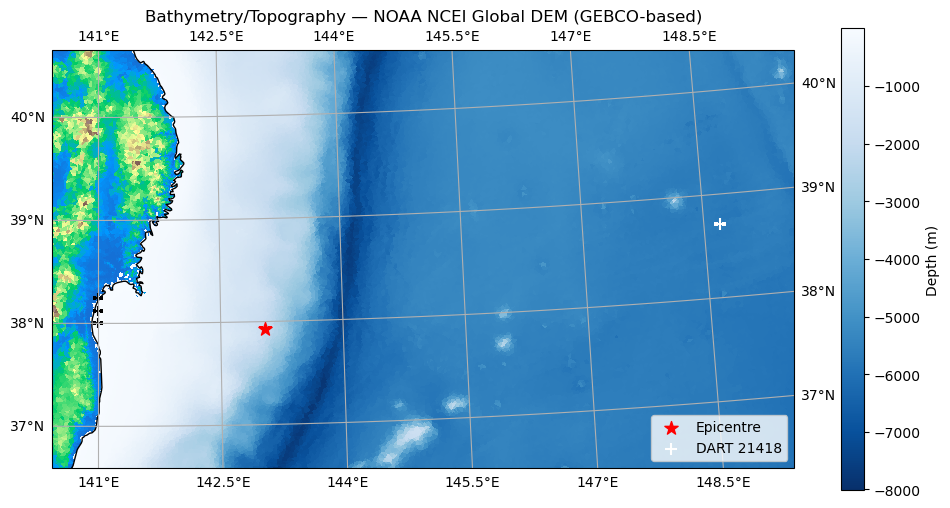

In [9]:
import cartopy.crs as ccrs

dplotter = anuga.Domain_plotter(domain, absolute=True)

fig, ax = plt.subplots(figsize=(10, 8), subplot_kw={'projection': ccrs.UTM(zone=54)})

md = 0.01  # wet/dry threshold

dplotter.triang.set_mask(dplotter.depth > md)
ax.tripcolor(dplotter.triang, facecolors=dplotter.elev, cmap='terrain', vmin=-200, vmax=2000)

ax.set_extent([450_000, 1_400_000, 4_050_000, 4_500_000], crs=ccrs.UTM(zone=54))
#ax.set_extent([100_000, 1_400_000, 3_900_000, 5_200_000], crs=ccrs.UTM(zone=54))

dplotter.triang.set_mask(dplotter.depth <= md)
img = ax.tripcolor(dplotter.triang, facecolors=dplotter.elev, cmap='Blues_r')
dplotter.triang.set_mask(None)

ax.scatter(x0, y0, marker='*', color='r', s=100, transform=ccrs.UTM(zone=54), label='Epicentre')
ax.scatter(gauges[21418].east, gauges[21418].north, marker='+', color='w', s=80,
           transform=ccrs.UTM(zone=54), label='DART 21418')
for k in [0, 1, 2]:
    ax.scatter(gauges[k].east, gauges[k].north, marker='+', color='k', s=60,
               transform=ccrs.UTM(zone=54))

ax.gridlines(draw_labels=True)
ax.coastlines(resolution='10m')
ax.legend(loc='lower right')
plt.colorbar(img, ax=ax, shrink=0.6, label='Depth (m)')
plt.title('Bathymetry/Topography — NOAA NCEI Global DEM (GEBCO-based)')
plt.tight_layout()

## Apply Earthquake Deformation

Generate a KL realisation of the slip field and compute the resulting
Okada surface deformation.  Re-run this cell to draw a new sample.

In [10]:
x = domain.centroid_coordinates[:, 0]
y = domain.centroid_coordinates[:, 1]

uE, uN, uZ, slips = okl.kl_deformation(
    x, y,
    xoff=x0 - xll,
    yoff=y0 - yll,
    E_subfault=10,
    N_subfault=10,
    sample='sobol',
    iseed=1234,
    **fault_parameters,
)

Elevation = domain.quantities['elevation'].centroid_values
Stage     = domain.quantities['stage'].centroid_values

Elevation[:] += uZ
Stage[:]     += uZ

print(f'uZ range   : {uZ.min():.2f} m to {uZ.max():.2f} m')
print(f'Stage range: {Stage.min():.2f} m to {Stage.max():.2f} m')

uZ range   : -9.45 m to 24.00 m
Stage range: -9.45 m to 1831.94 m


## Initial Stage After Deformation

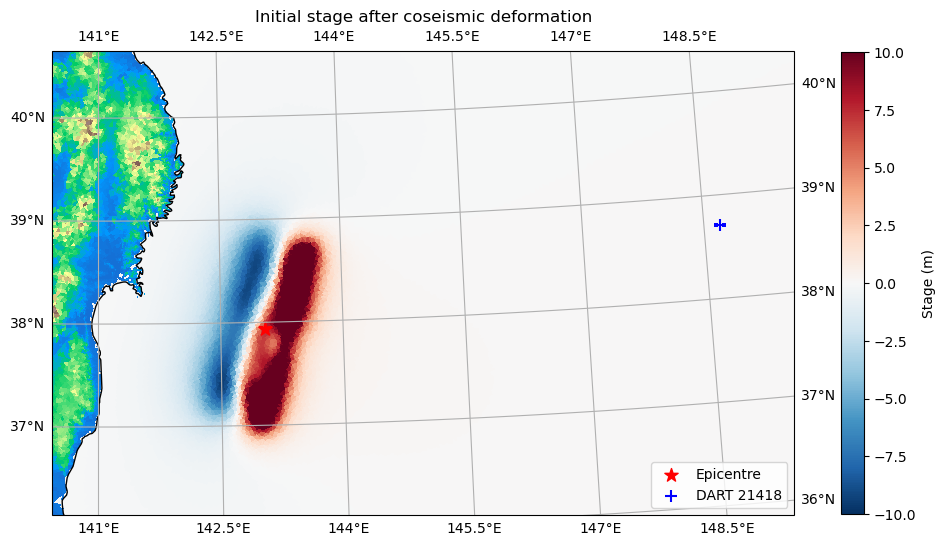

In [11]:
dplotter = anuga.Domain_plotter(domain, absolute=True)

fig, ax = plt.subplots(figsize=(10, 8), subplot_kw={'projection': ccrs.UTM(zone=54)})

dplotter.triang.set_mask(dplotter.depth > md)
ax.tripcolor(dplotter.triang, facecolors=dplotter.elev, cmap='terrain', vmin=-200, vmax=2000)

dplotter.triang.set_mask(dplotter.depth <= md)
img = ax.tripcolor(dplotter.triang, facecolors=dplotter.stage, cmap='RdBu_r', vmin=-10, vmax=10)
dplotter.triang.set_mask(None)

ax.scatter(x0, y0, marker='*', color='r', s=100, transform=ccrs.UTM(zone=54), label='Epicentre')
ax.scatter(gauges[21418].east, gauges[21418].north, marker='+', color='b', s=80,
           transform=ccrs.UTM(zone=54), label='DART 21418')

#ax.set_extent([450000, 1000000, 4050000, 4500000], crs=ccrs.UTM(zone=54))
ax.set_extent([450_000, 1_400_000, 4_000_000, 4_500_000], crs=ccrs.UTM(zone=54))
ax.gridlines(draw_labels=True)
ax.coastlines(resolution='10m')
ax.legend(loc='lower right')
plt.colorbar(img, ax=ax, shrink=0.6, label='Stage (m)')
plt.title('Initial stage after coseismic deformation')
plt.tight_layout()

## Boundary Conditions and Evolve

In [12]:
Br = anuga.Reflective_boundary(domain)
Bf = anuga.Flather_external_stage_zero_velocity_boundary(domain, lambda t: tide)

domain.set_boundary({
    'onshore':    Br,
    'bottom':     Bf,
    'ocean_east': Bf,
    'top':        Bf,
})

In [13]:
#from anuga.operators.collect_max_quantities_operator import Collect_max_quantities_operator

#max_min_collector = Collect_max_quantities_operator(domain)
max_collector = domain.max_quantities_operator

In [14]:
import time

min_  = 60.
hour_ = 3600.

# Nothing is sampled in here: every plot below is derived from the .sww, so
# gauge locations can be changed and the figures redrawn without re-evolving.
t0 = time.time()

for t in domain.evolve(yieldstep=2 * min_, finaltime=4.0 * hour_):
    domain.print_timestepping_statistics()

print(f'\nSimulation took {time.time() - t0:.1f} s')



--- GPU Domain (rank 0/1) ---
  Elements: 354946  |  Device: 0  |  GPU-aware MPI: no
+==============================================================================+
| GPU interface initialized: 1 MPI rank(s) on 1 GPU(s), OpenMP target offloading
+==============================================================================+
  GPU memory: 165 MB estimated required (device query not available)
  Reflective boundary: 110 edges
  Flather boundary: 434 edges
  Arrays mapped to device 0


[Rank 0] All fractional operators are GPU-safe, no GPU<->CPU sync needed


Time = 0.0000 (sec), steps=0 (0s), elapsed (0s), eta (??), mem=1.08GB


Time = 120.0000 (sec), delta t in [0.66539213, 0.66546713] (s), steps=181 (0s), elapsed (1s), eta (2m:19s), mem=1.08GB


Time = 240.0000 (sec), delta t in [0.66531293, 0.66539199] (s), steps=181 (0s), elapsed (1s), eta (1m:52s), mem=1.08GB


...

Time = 14040.0000 (sec), delta t in [0.66516307, 0.66525331] (s), steps=181 (0s), elapsed (1m:26s), eta (2s), mem=1.08GB


Time = 14160.0000 (sec), delta t in [0.66525356, 0.66531812] (s), steps=181 (0s), elapsed (1m:27s), eta (1s), mem=1.08GB


Time = 14280.0000 (sec), delta t in [0.66504513, 0.66526753] (s), steps=181 (0s), elapsed (1m:27s), eta (0s), mem=1.08GB


Time = 14400.0000 (sec), delta t in [0.66480570, 0.66504462] (s), steps=181 (0s), elapsed (1m:28s), eta (0s), mem=1.08GB



Simulation took 88.6 s


## Read the Results Back from the `.sww`

Everything below reads the `.sww` rather than the live domain, so gauge
positions, snapshot times and map extents can all be changed and the figures
redrawn without re-running the evolve.


In [15]:
sww_file = domain.get_name() + '.sww'
sp = anuga.SWW_plotter(sww_file, absolute=True)
triang = sp.triang

sww_time  = np.asarray(sp.time)
sww_elev  = np.asarray(sp.elev)
sww_stage = np.asarray(sp.stage)
sww_depth = np.asarray(sp.depth)

# SWW_plotter's max_* properties return the max_*_c fields written by
# set_collect_max_quantities(store_to_sww=True), which are true every-timestep
# maxima, and fall back to a max over the stored frames if they are absent.
# For a tsunami the stored fields are much the better choice: scanning frames
# samples the wave at the yieldstep and picks up artificial pulsing.
sww_max_stage = np.asarray(sp.max_stage)
sww_max_depth = np.asarray(sp.max_depth)
sww_max_speed = np.asarray(sp.max_speed)

max_source = ('stored max_*_c (every timestep)' if sp._max_stage_c is not None
              else 'derived from stored frames')

# Kept only to show what frame-scanning would have cost, below.
scan_max_stage = sww_stage.max(axis=0)

md = 0.01                                    # wet/dry threshold


def gauge_cell(gauge):
    """Index of the .sww centroid nearest a gauge, which carries absolute UTM."""
    return int(np.argmin((sp.xc - gauge.east) ** 2 + (sp.yc - gauge.north) ** 2))


def gauge_series(gauge, quantity='stage'):
    """(time, values) at the cell nearest a gauge, straight from the .sww."""
    return sww_time, np.asarray(getattr(sp, quantity))[:, gauge_cell(gauge)]


print(f'{sww_file}: {len(sww_time)} frames, '
      f'{sww_time[0]:.0f}-{sww_time[-1]:.0f} s, {sp.xc.size} cells')
print(f'maxima: {max_source}')


tohoku_open_dem.sww: 121 frames, 0-14400 s, 354946 cells
maxima: stored max_*_c (every timestep)


## Maximum Stage

max wet stage  stored max_*_c (every timestep):  47.78 m
               scanned from frames            :  45.49 m


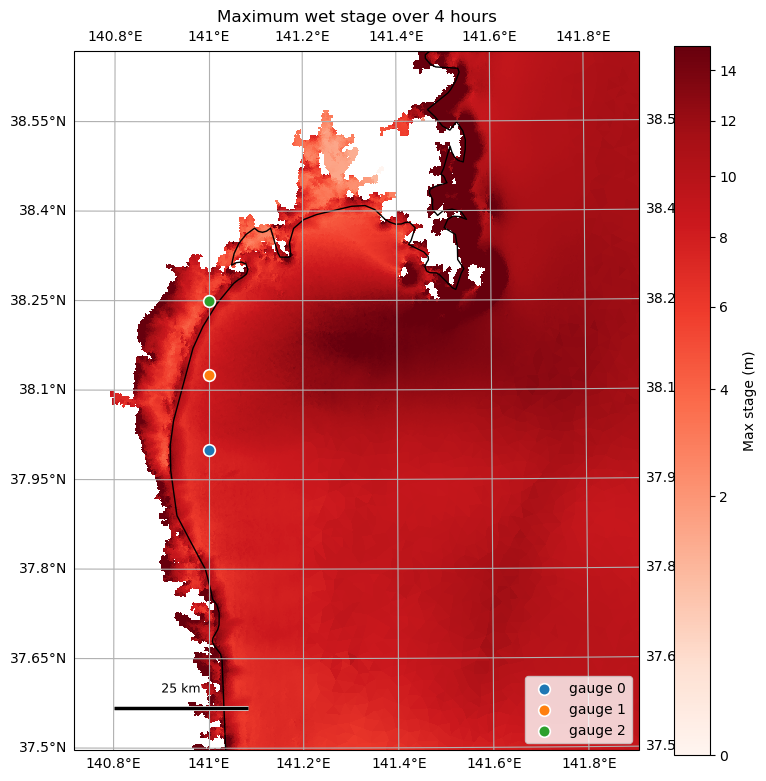

In [16]:
from matplotlib.colors import PowerNorm

wet_max_stage = np.where(sww_max_depth >= md, sww_max_stage, np.nan)

# The .sww only stores yieldsteps, so its maximum can miss a peak that the
# operator (which sees every timestep) caught.  Quantify the gap.
# What the 2-minute frame sampling would have cost, had we scanned instead.
# Mask both the same way, or the comparison picks up dry mountain tops, where
# stage is simply the elevation.
scanned = np.where(sww_max_depth >= md, scan_max_stage, np.nan)
print(f'max wet stage  {max_source:31s}: {np.nanmax(wet_max_stage):6.2f} m')
print(f'               {"scanned from frames":31s}: {np.nanmax(scanned):6.2f} m')

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={'projection': ccrs.UTM(zone=54)})

# Square-root norm: keeps the ~20 m runup peaks unsaturated while retaining
# contrast in the 2-8 m offshore range.
img = ax.tripcolor(triang, facecolors=wet_max_stage,
                   cmap='Reds', norm=PowerNorm(gamma=0.5, vmin=0, vmax=15))

#ax.scatter(x0, y0, marker='*', color='b', s=100, transform=ccrs.UTM(zone=54), label='Epicentre')
#ax.scatter(gauges[21418].east, gauges[21418].north, marker='+', color='w', s=80,
#           transform=ccrs.UTM(zone=54), label='DART 21418')
for k in [0, 1, 2]:
    ax.scatter(gauges[k].east, gauges[k].north, marker='o', s=70,
               edgecolor='w', linewidth=1.2, zorder=5,
               transform=ccrs.UTM(zone=54), label=f'gauge {k}')

ax.set_extent(closeup_extent, crs=ccrs.UTM(zone=54))   # red box on the locality map
ax.gridlines(draw_labels=True)
ax.coastlines(resolution='10m')
add_scalebar(ax, length_km=25)
ax.legend(loc='lower right')
plt.colorbar(img, ax=ax, shrink=1.0, label='Max stage (m)')
plt.title('Maximum wet stage over 4 hours')
plt.tight_layout()

## Stage Snapshots over the Close-up Region

Actual stage at selected times, read back from the `.sww` output, over the same
Tohoku coastal box outlined in red on the locality map.  The wave leaves the
source to the east and reaches the coast at around 16 minutes.


Text(0.5, 0.91, 'Stage over the Tohoku coast')

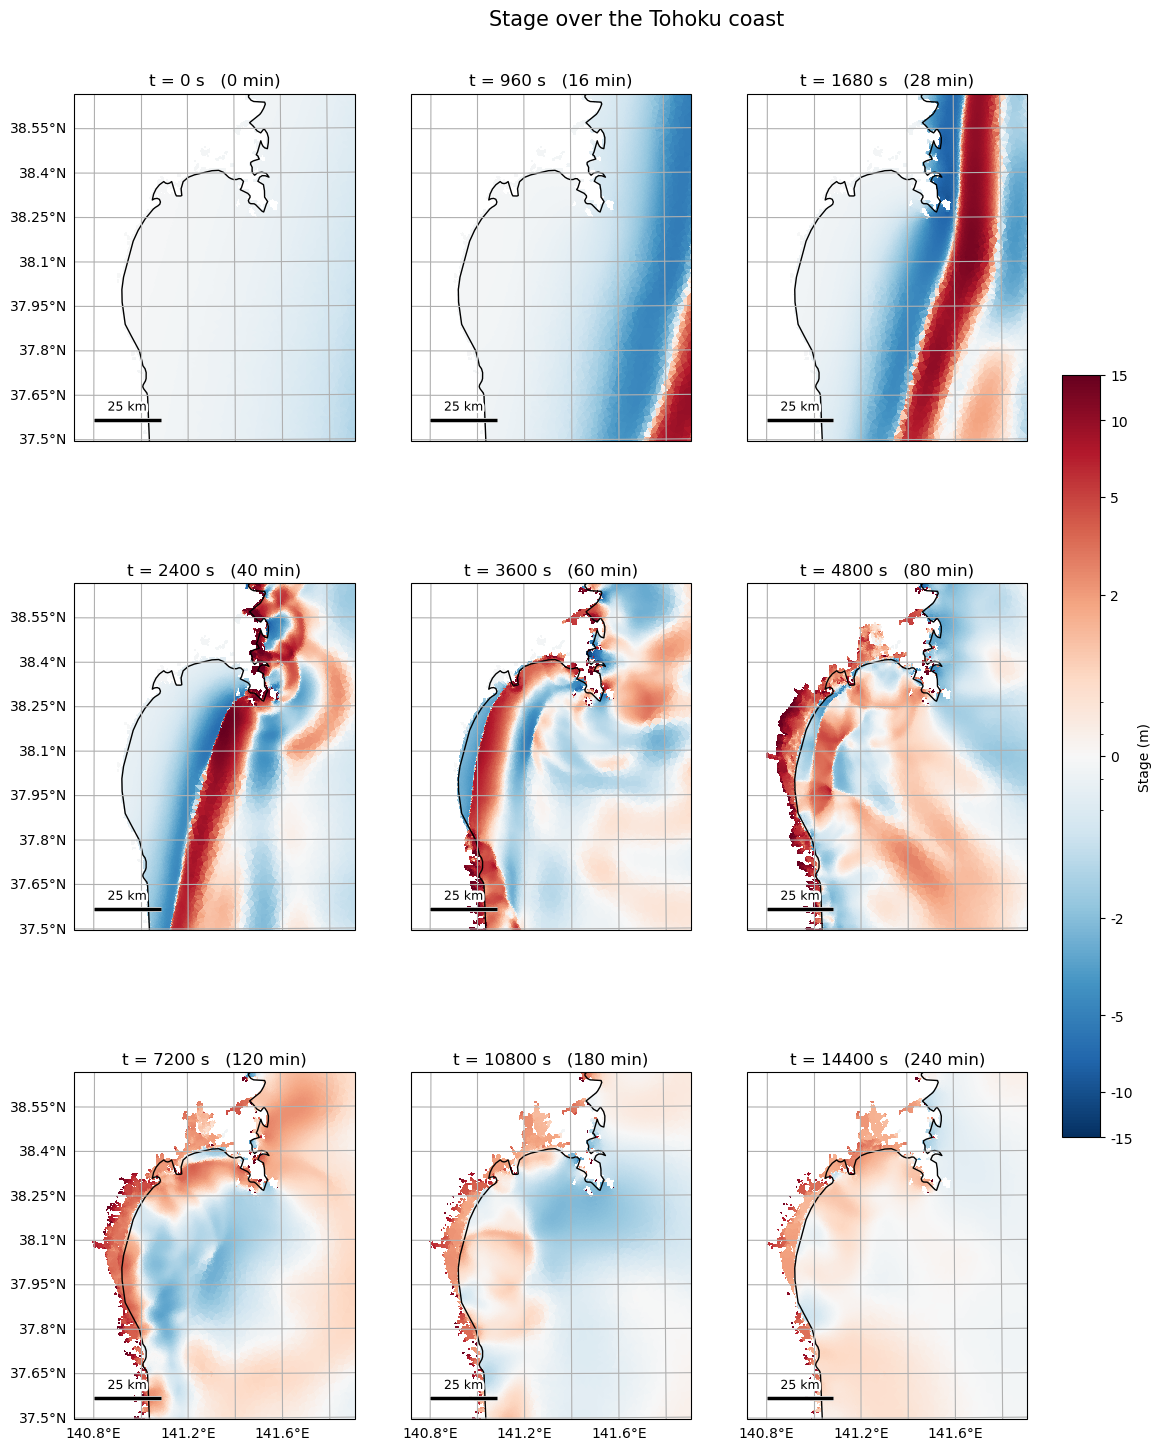

In [17]:
from matplotlib.colors import AsinhNorm

# Initial deformation, first arrival (960 s), then run-up, inundation and the
# long decay out to the end of the run at 4 hours.
snapshot_times = [0., 960., 1680., 2400., 3600., 4800., 7200., 10800., 14400.]

# Same +/-15 m span and the same square-root-like stretch as the maximum-stage
# figure above, but centred on 0 so the drawdown ahead of each crest is visible.
# A given red is then the same stage in both figures.
norm = AsinhNorm(linear_width=1.0, vmin=-15, vmax=15)

ncol = 3
nrow = int(np.ceil(len(snapshot_times) / ncol))

fig, axes = plt.subplots(nrow, ncol, figsize=(15, 18),
                         subplot_kw={'projection': ccrs.UTM(zone=54)})
axes = axes.ravel()

for ax, t_snap in zip(axes, snapshot_times):
    f = int(np.argmin(np.abs(sp.time - t_snap)))
    wet_stage = np.where(sp.depth[f] > md, sp.stage[f], np.nan)

    triang.set_mask(sp.depth[f] <= md)
    im = ax.tripcolor(triang, facecolors=wet_stage, cmap='RdBu_r', norm=norm)
    triang.set_mask(None)

    ax.set_extent(closeup_extent, crs=ccrs.UTM(zone=54))
    ax.coastlines(resolution='10m')
    add_scalebar(ax, length_km=25)

    # Label only the outer edge of the grid, or neighbouring panels collide.
    k = list(axes).index(ax)
    gl = ax.gridlines(draw_labels=True)
    gl.top_labels = gl.right_labels = False
    gl.left_labels = (k % ncol == 0)
    gl.bottom_labels = (k >= len(snapshot_times) - ncol)

    ax.set_title(f't = {sp.time[f]:.0f} s   ({sp.time[f] / 60:.0f} min)')

for ax in axes[len(snapshot_times):]:
    ax.set_visible(False)

# AsinhNorm brings its own tick locator, so set the ticks after the fact.
ticks = [-15, -10, -5, -2, 0, 2, 5, 10, 15]
cbar = fig.colorbar(im, ax=axes.tolist(), shrink=0.55, pad=0.03, label='Stage (m)')
cbar.set_ticks(ticks)
cbar.set_ticklabels([str(t) for t in ticks])
fig.suptitle('Stage over the Tohoku coast', y=0.91, fontsize=15)


## Nearshore Gauge Time Series

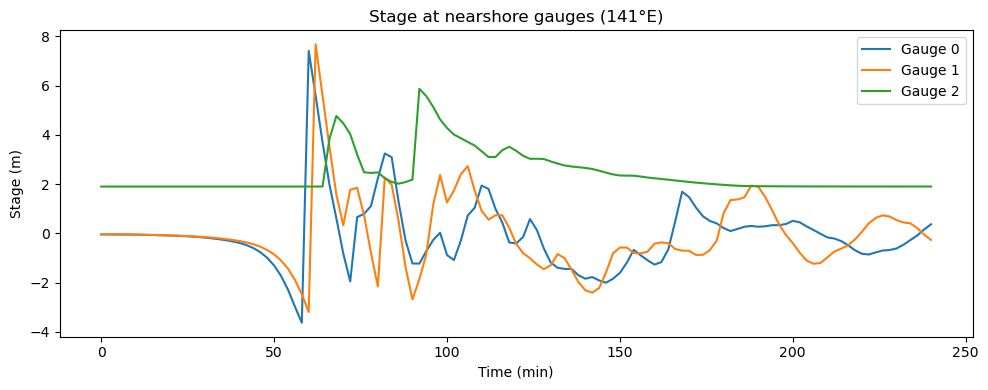

In [18]:
fig, ax = plt.subplots(figsize=(10, 4))

for k in [0, 1, 2]:
    t, stage = gauge_series(gauges[k])
    ax.plot(t / 60, stage, label=f'Gauge {k}')

ax.set_xlabel('Time (min)')
ax.set_ylabel('Stage (m)')
ax.legend()
ax.set_title('Stage at nearshore gauges (141\u00b0E)')
plt.tight_layout()


## Comparison with DART 21418 Observations

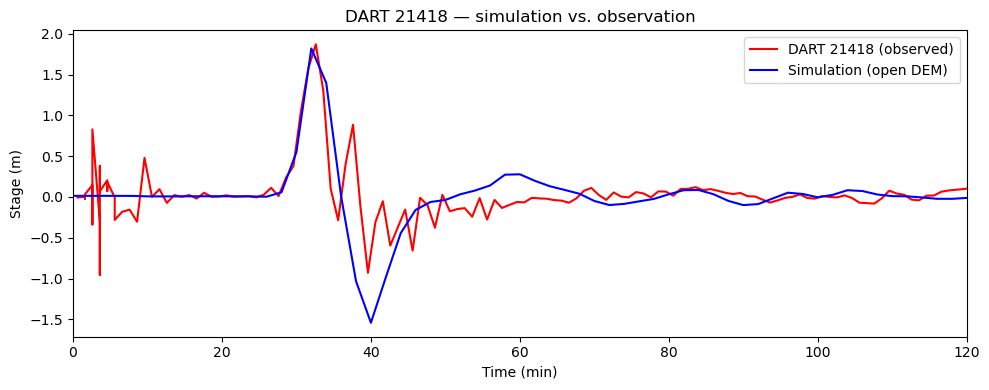

In [19]:
obs = np.loadtxt('21418_notide.txt')

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(obs[:, 0] / 60, obs[:, 1], 'r', label='DART 21418 (observed)')
t, stage_21418 = gauge_series(gauges[21418])
ax.plot(t / 60, stage_21418, 'b', label='Simulation (open DEM)')
ax.set_xlim(0, 120)
ax.set_xlabel('Time (min)')
ax.set_ylabel('Stage (m)')
ax.legend()
ax.set_title('DART 21418 — simulation vs. observation')
plt.tight_layout()

## Sendai: Stage and Run-up

The Sendai plain is the flattest, most exposed stretch of this coast.  The
gauges below run from offshore, across the shoreline, to points several
kilometres inland, and the transect at 38.21°N follows the water inland to
the run-up limit.  All of it is read from the `.sww`, so the sites can be
moved and this section re-run on its own.


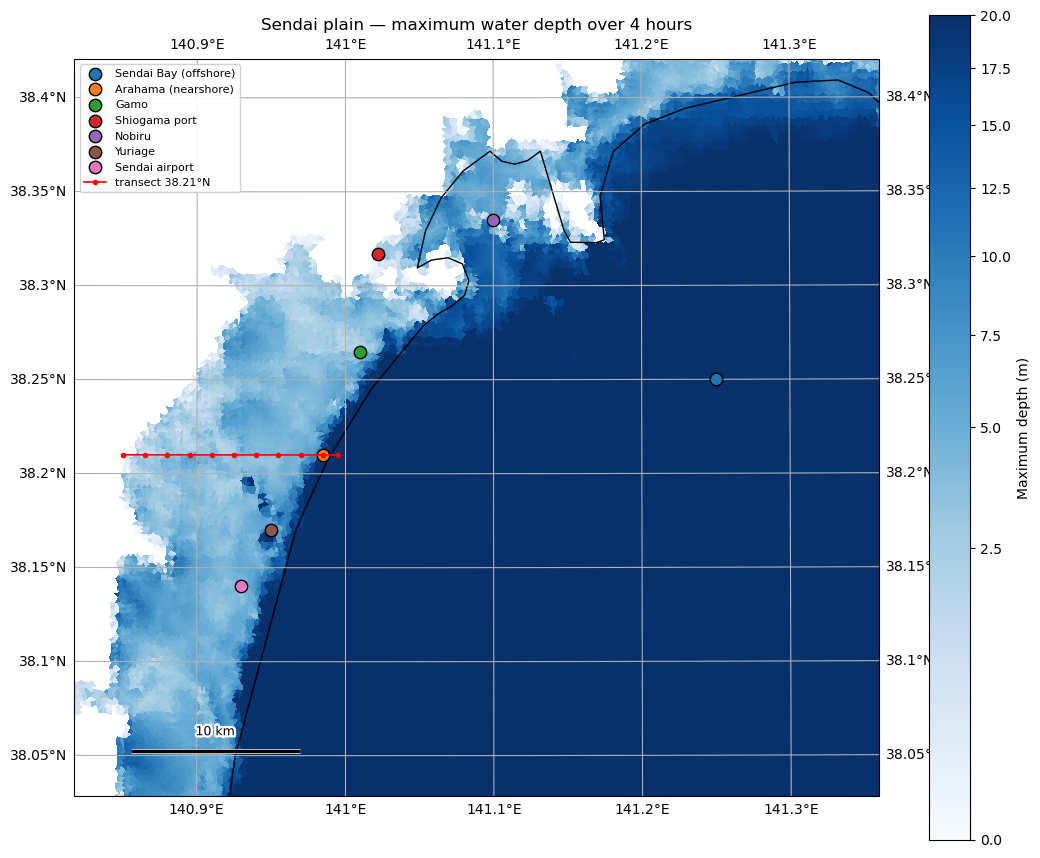

In [20]:
sendai_extent = [484_000, 531_500, 4_209_000, 4_252_500]   # UTM 54N metres

wet_max_depth = np.where(sww_max_depth >= md, sww_max_depth, np.nan)

fig, ax = plt.subplots(figsize=(11, 10), subplot_kw={'projection': ccrs.UTM(zone=54)})

img = ax.tripcolor(triang, facecolors=wet_max_depth, cmap='Blues',
                   norm=PowerNorm(gamma=0.5, vmin=0, vmax=20))

for name, g in sendai_gauges.items():
    ax.scatter(g.east, g.north, marker='o', s=80, edgecolor='k', linewidth=1.0,
               zorder=6, transform=ccrs.UTM(zone=54), label=name)

ax.plot([g.east for g in transect_gauges], [g.north for g in transect_gauges],
        'r.-', lw=1.2, ms=6, zorder=6, transform=ccrs.UTM(zone=54),
        label=f'transect {transect_lat}\u00b0N')

ax.set_extent(sendai_extent, crs=ccrs.UTM(zone=54))
ax.coastlines(resolution='10m')
ax.gridlines(draw_labels=True)
add_scalebar(ax, length_km=10)
ax.legend(loc='upper left', fontsize=8, framealpha=0.9)
plt.colorbar(img, ax=ax, shrink=0.85, label='Maximum depth (m)')
plt.title('Sendai plain \u2014 maximum water depth over 4 hours')
plt.tight_layout()


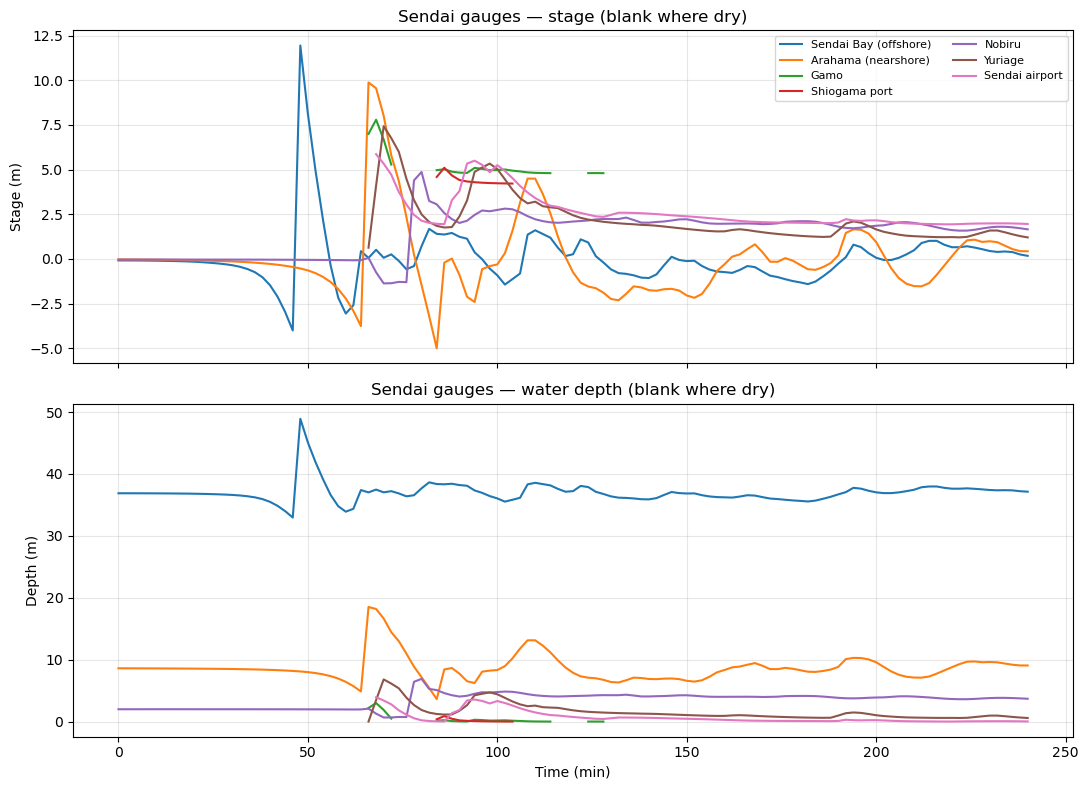

In [21]:
fig, axes = plt.subplots(2, 1, figsize=(11, 8), sharex=True)

for name, g in sendai_gauges.items():
    t, stage = gauge_series(g)
    _, depth = gauge_series(g, 'depth')

    # On a dry cell 'stage' is just the ground elevation, which would draw a
    # flat line at the topographic height before the wave arrives.  Blank it.
    wet = depth > md
    axes[0].plot(t / 60, np.where(wet, stage, np.nan), label=name)
    axes[1].plot(t / 60, np.where(wet, depth, np.nan), label=name)

axes[0].set_ylabel('Stage (m)')
axes[0].set_title('Sendai gauges \u2014 stage (blank where dry)')
axes[0].legend(fontsize=8, ncol=2)
axes[0].grid(alpha=0.3)

axes[1].set_ylabel('Depth (m)')
axes[1].set_xlabel('Time (min)')
axes[1].set_title('Sendai gauges \u2014 water depth (blank where dry)')
axes[1].grid(alpha=0.3)

plt.tight_layout()


In [22]:
def gauge_summary(g):
    i = gauge_cell(g)
    stage = sww_stage[:, i]
    depth = sww_depth[:, i]
    wet   = depth > md
    # Only wet frames count: on a dry cell 'stage' is just the elevation.
    t_arr     = sww_time[wet][0] / 60 if wet.any() else np.nan
    max_stage = stage[wet].max() if wet.any() else np.nan
    return dict(elev=sww_elev[i], dry0=not wet[0], max_stage=max_stage,
                max_depth=depth.max(), t_arrive=t_arr, ever_wet=wet.any(),
                dist=np.hypot(sp.xc[i] - g.east, sp.yc[i] - g.north))


print(f"{'site':24s}{'elev':>8}{'dry@0':>7}{'max stage':>11}"
      f"{'max depth':>11}{'wet from':>10}{'cell dx':>9}")
print('-' * 80)
for name, g in sendai_gauges.items():
    s = gauge_summary(g)
    print(f"{name:24s}{s['elev']:8.1f}{str(s['dry0']):>7}{s['max_stage']:11.2f}"
          f"{s['max_depth']:11.2f}{s['t_arrive']:10.0f}{s['dist']:9.0f}")

print()
print(f'Inland transect at {transect_lat}\u00b0N')
print(f"{'lon':>10}{'inland km':>11}{'elev':>8}{'max stage':>11}{'max depth':>11}")
print('-' * 51)
coast_east = transect_gauges[1].east
for g in transect_gauges:
    s = gauge_summary(g)
    print(f'{g.long:10.3f}{(coast_east - g.east) / 1000:11.1f}{s["elev"]:8.1f}'
          f'{s["max_stage"]:11.2f}{s["max_depth"]:11.2f}')


site                        elev  dry@0  max stage  max depth  wet from  cell dx
--------------------------------------------------------------------------------
Sendai Bay (offshore)      -37.0  False      11.95      48.92         0      127
Arahama (nearshore)         -8.6  False       9.88      18.52         0       47
Gamo                         4.8   True       7.79       3.00        66       38
Shiogama port                4.2   True       5.11       0.90        84       64
Nobiru                      -2.0  False       4.87       6.91         0       68
Yuriage                      0.6   True       7.43       6.82        66       64
Sendai airport               1.9   True       5.87       3.95        68       76

Inland transect at 38.21°N
       lon  inland km    elev  max stage  max depth
---------------------------------------------------
   140.995       -0.9   -14.5       8.76      23.27
   140.985        0.0    -8.6       9.88      18.52
   140.970        1.3     1.3      